In [1]:
from utils import *

import sinter # makes implementation faster
import os

In [2]:
def surface_code_memory(p:float, # error rate 
                        d: int, # code distance
                        num_rounds = None, # number of repeated measurements
                        ):
    
    if not round:
        num_rounds = 3 * d

    num_qubits = (2*d-1)**2

    num_measure_q = 2 * d * (d - 1)
    num_data_q = 2 * d**2 - 2 * d + 1

    nrows = 2*d - 1; ncols = 2*d - 1

    qindex = np.arange(0, num_qubits, 1)
    qgrid = np.reshape(qindex, (nrows, ncols)).T


    # Build coordinate lookup dictionary
    coord_map = {}
    for i in range(nrows):
        for j in range(ncols):
            coord_map[qgrid[i, j]] = (i, j)


    # Build coordinates
    qposition = [f"QUBIT_COORDS({j}, {i}, 0) {qgrid[j,i]}" 
                    for i in range(nrows) 
                    for j in range(ncols)]
    qcoords = "\n".join(qposition)

    # Then use the dictionary for lookups
    measure_q = []
    data_q = []
    data_q_index = []
    measure_q_index = []

    for i in range(1, num_qubits, 2):
        x, y = coord_map[i]
        measure_q.append([x, y, i])
        measure_q_index.append(i)


    for i in range(0, num_qubits, 2):
        x, y = coord_map[i]
        data_q.append([x, y, i])
        data_q_index.append(i)
        

    zmeasure_q = np.array([[x, y, qgrid[x,y]]
                for y in range(1, nrows - 1, 2)
                for x in range(0, ncols, 2)], dtype =int)


    xmeasure_q = np.array([[x, y, qgrid[x,y]]
                for y in range(0, nrows, 2)
                for x in range(1, ncols - 1, 2)], dtype = int)

    measure_hist = np.zeros(num_qubits, dtype = int)

    j  = 0 

    for i in range(1,num_qubits,2):
        measure_hist[i] = -len(measure_q) + j
        j +=1


    # stabilizer measurement instructions =========

    # step 01

    hadamard_on_xmeasure_q = hadamard(qubits=xmeasure_q[:,2]) # applies hadamard on x stabilizer measure qubits
    hadamard_on_xmeasure_q += depolarize1(qubits=xmeasure_q[:,2], error_rate=p) # add depolarizing noise

    id_on_zmeasure_q = identity(qubits=zmeasure_q[:,2]) # works as a idle step 
    id_on_zmeasure_q +=  depolarize1(qubits=zmeasure_q[:,2], error_rate=p) # add depolarizing noise

    id_on_data_q = identity(qubits=data_q_index)
    id_on_data_q += depolarize1(qubits=data_q_index, error_rate=p)

    # step 02


    cnot01_q = [(qgrid[j,i], qgrid[j+1,i]) 
                for i in range(0, nrows, 2)
                for j in range(1, ncols, 2)] + [(qgrid[j + 1, i], qgrid[j, i])
                                                for i in range(1, nrows, 2)
                                                for j in range(0, ncols - 1, 2)]

    cnot01 = cnot(qubits=cnot01_q)
    idle_q01 = [qgrid[0, i] for i in range(0, nrows, 2)] + [qgrid[-1, i] for i in range(1, nrows, 2)]
    cnot01 += identity(qubits=idle_q01)
    cnot01 += depolarize2(qubits=cnot01_q, error_rate=p)
    cnot01 += depolarize1(
        idle_q01, error_rate= p
    )


    cnot02_q = [(qgrid[x, y], qgrid[x, y + 1])
                for x in range(1, nrows, 2)
                for y in range(0, ncols - 2, 2)] +[(qgrid[x, y + 1], qgrid[x, y])
                                                for x in range(0, nrows, 2)
                                                for y in range(1, ncols, 2)]

    cnot02 = cnot(qubits=cnot02_q)
    idle_q02 = [qgrid[i, 0] for i in range(0, nrows, 2)] + [qgrid[i, -1] for i in range(1, nrows, 2)]
    cnot02 += identity(qubits=idle_q02)
    cnot02 += depolarize2(qubits=cnot02_q, error_rate=p)
    cnot02 += depolarize1(
        idle_q02, error_rate= p
    )


    cnot03_q = [(qgrid[j,i], qgrid[j,i+1])
                for i in range(0, nrows-1, 2)
                for j in range(0, ncols, 2)]  + [(qgrid[j,i+1], qgrid[j,i])
                                                for i in range(1, nrows-1, 2)
                                                for j in range(1, ncols, 2)]



    cnot03 = cnot(qubits=cnot03_q)
    idle_q03 = [qgrid[i, -1] for i in range(0, nrows, 2)] + [qgrid[i, 0] for i in range(1, nrows, 2)]
    cnot03 += identity(qubits=idle_q03)
    cnot03 += depolarize2(qubits=cnot03_q, error_rate=p)
    cnot03 += depolarize1(
        idle_q03, error_rate= p
    )





    cnot04_q = [(qgrid[j+1,i], qgrid[j,i])
                for i in range(0, nrows, 2)
                for j in range(0, ncols-1, 2)]  + [(qgrid[j,i], qgrid[j+1,i])
                                                for i in range(1, nrows, 2)
                                                for j in range(1, ncols-1, 2)]


    cnot04 = cnot(qubits=cnot04_q)
    idle_q04 = [qgrid[0, i] for i in range(1, nrows, 2)] + [qgrid[-1, i] for i in range(0, nrows, 2)]
    cnot04 += identity(qubits=idle_q04)
    cnot04 += depolarize2(qubits=cnot04_q, error_rate=p)
    cnot04 += depolarize1(
        idle_q04, error_rate= p
    )

    measure_measure_q = measure_z(qubits=zmeasure_q[:,2], error_rate=p, reset=False) + measure_z(qubits=xmeasure_q[:,2], error_rate=p, reset=False)

    reset_measure_q =  reset_z(qubits=zmeasure_q[:,2], reset_error=p) + reset_z(qubits=xmeasure_q[:,2], reset_error=p)



    measure_stabilizers = hadamard_on_xmeasure_q + id_on_zmeasure_q + id_on_data_q +  tick()
    measure_stabilizers += cnot01 + tick()
    measure_stabilizers += cnot02 + tick()
    measure_stabilizers += cnot03 + tick()
    measure_stabilizers += cnot04 + tick()
    measure_stabilizers += hadamard_on_xmeasure_q + id_on_zmeasure_q + id_on_data_q +  tick()
    measure_stabilizers += measure_measure_q + tick()
    measure_stabilizers += reset_measure_q + tick()






    circ_script = ''

    circ_script += qcoords 

    circ_script += reset_x(qubits=data_q_index, reset_error=p) 
    circ_script += reset_z(qubits=measure_q_index, reset_error=p) + tick()

    circ_script += measure_stabilizers



    # detectors for initial X stabilizers

    initial_detectors = ''

    for i in range(int(num_measure_q/2)):
        initial_detectors += f'DETECTOR({xmeasure_q[i, 0]}, {xmeasure_q[i, 1]}, 0) rec[{-int(num_measure_q/2) + i}]\n'

    circ_script += initial_detectors



    # stabilizer measurement for d rounds

    # num_rounds = d

    stab_measurement_round = f'REPEAT {num_rounds} ' + '{\n SHIFT_COORDS(0, 0, 1)\n' + f'{measure_stabilizers}'

    detectors = ''

    for i in range(int(num_measure_q/2)):
        detectors += f'DETECTOR({zmeasure_q[i, 0]}, {zmeasure_q[i, 1]}, 0) rec[{-num_measure_q + i}] rec[{-2 * num_measure_q + i}]\n'

    for i in range(int(num_measure_q/2)):
        detectors += f'DETECTOR({xmeasure_q[i, 0]}, {xmeasure_q[i, 1]}, 0) rec[{-int(num_measure_q/2) + i}] rec[{- 3 * int(num_measure_q/2) + i}]\n'


    stab_measurement_round += detectors + '}'


    circ_script += stab_measurement_round


    circ_script += measure_x(qubits=data_q_index, error_rate  = 0, reset=False)

    measure_record = [None for i in range(num_qubits)] # ith element is time when qubit i was measurement

    for i in range(int(num_measure_q/2)):
        measure_record[xmeasure_q[i, 2]] = - num_data_q - int(num_measure_q/2) + i
        measure_record[zmeasure_q[i, 2]] = - num_data_q - int(num_measure_q) + i

    for i in range(num_data_q):
        measure_record[data_q[i][2]] = - num_data_q + i


    zstabilizer_info = [] # has information about which Z stabilizer and associated data qubit they made of

    zstabilizer_info += [[qgrid[0,y], qgrid[0,y-1], qgrid[0,y+1], qgrid[1,y]] for y in range(1, ncols-1, 2)]

    zstabilizer_info += [[qgrid[x,y], qgrid[x-1,y], qgrid[x+1,y], qgrid[x,y+1], qgrid[x,y-1]]                    
                        for x in range(2,nrows-1,2) 
                        for y in range(1,ncols-1,2)]


    zstabilizer_info += [[qgrid[-1,y],qgrid[-1,y-1],qgrid[-1,y+1],qgrid[-2,y]]
                        for y in range(1,nrows - 1, 2) 
                        ]


    xstabilizer_info = [] # has information about which X stabilizer and associated data qubit they made of

    xstabilizer_info += [[qgrid[x, 0], qgrid[x -1, 0], qgrid[x+1, 0], qgrid[x, 1]] for x in range(1, nrows, 2)]

    xstabilizer_info += [[qgrid[x,y], qgrid[x-1,y], qgrid[x+1,y], qgrid[x,y+1], qgrid[x,y-1] ]
                        for y in range(2, ncols - 2, 2)
                        for x in range(1, nrows, 2)]

    xstabilizer_info += [[qgrid[x, -1], qgrid[x -1, -1], qgrid[x+1, -1], qgrid[x, -2]]
                        for x in range(1, nrows, 2)]

    final_detectors = '\nSHIFT_COORDS(0, 0, 1)\n'



    for s in xstabilizer_info:
        x, y = coord_map[s[0]]
        final_detectors += f'DETECTOR({x}, {y}, 0) '
        for ri in s:
            final_detectors += f'rec[{measure_record[ri]}] '
        final_detectors += '\n'


    circ_script += final_detectors


    zlogical = [qgrid[x, 0] for x in range(0, nrows, 2)] # requires for the Z memory experiment 

    xlogical = [qgrid[0, y] for y in range(0, ncols, 2)]


    observable = 'OBSERVABLE_INCLUDE(0)'

    for i in range(d):

        observable += f' rec[{measure_record[xlogical[i]]}]'


    circ_script += observable


    circ = stim.Circuit(circ_script)


    return circ

In [3]:
def logical_err(circ:stim.Circuit, # stim circuit  
                shots: int, 
                ):
    
    sampler = circ.compile_detector_sampler()
    syndrome, actual_observables = sampler.sample(shots = shots,separate_observables = True)
    model = circ.detector_error_model(decompose_errors=True)
    matching = pymatching.Matching.from_detector_error_model(model)
    predicted_observables = matching.decode_batch(syndrome)
    num_errors = np.sum(np.any(predicted_observables != actual_observables, axis=1))

    return num_errors/shots


In [ ]:
d = [3, 5, 7, 9, 11]
p = np.logspace(-4, -1.5, 10)

shots= int(1e5)

log_err_rates = []


print('Estimated time is around 5-10 minutes...')

load_data = False # change to True to use pre-saved data

if load_data:
    for di in d:
        print(f'\rSimulating L = {di}', end="")
        err = np.zeros_like(p)
        for i in range(len(p)):
            circ = surface_code_memory(p[i], di, num_rounds=di)
            err[i] = np.loadtxt(f'data/log_errors-dist-{di}-rounds-{di}.txt')
        log_err_rates.append(err)
else:
    for di in d:
        print(f'\rSimulating L = {di}', end="")
        err = np.zeros_like(p)
        for i in range(len(p)):
            circ = surface_code_memory(p[i], di, num_rounds=di)
            err[i] = logical_err(circ, shots = shots)
        np.savetxt(f'data/log_errors-dist-{di}-rounds-{di}.txt', err)
        log_err_rates.append(err)

Estimated time is around 5 minutes...
Simulating L = 11

In [5]:
# Finding threshold through finite scaling : 


find_threshold = False # set to False to use already found value

if find_threshold:

    d1 = 7; d2 = 11
    shots = int(1e5)

    pi = 5e-3 # starting error rate
    dpi = 5e-4 # size of steps 


    circ_d1 = surface_code_memory(pi, d1, num_rounds=3 * d1)
    circ_d2 = surface_code_memory(pi, d2, num_rounds=3 * d2)


    log_err_d1 = logical_err(circ=circ_d1, shots = shots )
    log_err_d2 = logical_err(circ=circ_d2, shots = shots )


    while log_err_d1 > log_err_d2:


        pi += dpi 
        print(f"\rTrying at {pi}", end="")

        circ_d1 = surface_code_memory(pi, d1, num_rounds=3 * d1)
        circ_d2 = surface_code_memory(pi, d2, num_rounds=3 * d2)


        log_err_d1 = logical_err(circ=circ_d1, shots = shots )
        log_err_d2 = logical_err(circ=circ_d2, shots = shots )


    p_threshold = pi 

else:

    p_threshold = 0.0065  


print(f'\nThreshold found at {p_threshold}')



Threshold found at 0.0065


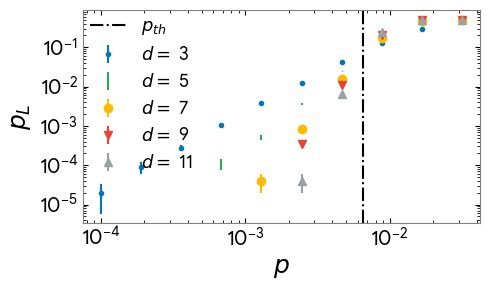

In [7]:
fig, ax = plt.subplots(figsize=(5,3))


for i in range(len(d)):

    log_err_di = log_err_rates[i]
    std_err = (log_err_di * (1 - log_err_di)/shots)**0.5

    ax.errorbar(p, 
                log_err_rates[i], 
                yerr = std_err, 
                label = rf'$d = $ {d[i]}', 
                color = google[i], 
                linestyle = '', 
                marker = marks[i]
                )

ax.axvline(x = p_threshold, linestyle='-.', label = r'$p_{th}$', color = 'k')


for spine in ax.spines.values():
    spine.set_edgecolor('gray')

plt.tick_params(top=True, left=True, right=True, bottom=True,
               direction="in", axis='both', which='both', 
               labelsize=15, color='k')

ax.set_xscale('log')
ax.set_yscale('log')

font2 = {'family':'Google Sans', 'color':'black', 'size':18}

plt.xlabel(r"$p$", fontdict=font2)
plt.ylabel(r"$p_L$", fontdict=font2)


plt.legend(
    fontsize=13,  # Slightly smaller font for external legend
    ncol=1,  # Fewer columns for vertical space 
    loc='best', 
    frameon=False,
    borderaxespad=0.  # Removes padding between axes and legend
)

plt.tight_layout(rect=[0, 0, 1, 1])  # Adjust right margin to make space
plt.savefig('figs/log_err.jpeg',bbox_inches='tight', dpi = 500)
plt.show()

In [8]:
import stim, sinter, pymatching

# must use this version of sinter

print(stim.__version__)
print(sinter.__version__)
print(pymatching.__version__)

1.15.0
1.14.0
2.3.1


In [9]:
# Using sinter for efficient error sampling 

import sinter
import os
from typing import List


noise = 1e-3

surface_code_tasks = [
    sinter.Task(
        circuit = surface_code_memory(p = noise, d = d, num_rounds=3*d),
        json_metadata={'d': d, 'r': d * 3, 'p': noise},
    )
    for d in [3, 5, 7, 9]
]

collected_surface_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=5_000_000,
    max_errors=100,
    print_progress=True,
)

Starting 48 workers...
4 tasks left:
  workers    decoder eta shots_left errors_left json_metadata   
       12 pymatching <1m    4996655          79 d=3,r=9,p=0.001 
       12 pymatching   ?    5000000         100 d=5,r=15,p=0.001
       12 pymatching   ?    5000000         100 d=7,r=21,p=0.001
       12 pymatching   ?    5000000         100 d=9,r=27,p=0.001
3 tasks left:
  workers    decoder eta shots_left errors_left json_metadata   
       16 pymatching <1m    4983275          97 d=5,r=15,p=0.001
       16 pymatching   ?    5000000         100 d=7,r=21,p=0.001
       16 pymatching   ?    5000000         100 d=9,r=27,p=0.001
3 tasks left:
  workers    decoder eta shots_left errors_left json_metadata   
       16 pymatching <1m    4900673          46 d=5,r=15,p=0.001
       16 pymatching <1m    4996378         100 d=7,r=21,p=0.001
       16 pymatching   ?    5000000         100 d=9,r=27,p=0.001
3 tasks left:
  workers    decoder        eta shots_left errors_left json_metadata   
    

In [10]:
import scipy.stats

# Compute the line fit.
xs = []
ys = []
log_ys = []
for stats in collected_surface_code_stats:
    d = stats.json_metadata['d']
    if not stats.errors:
        print(f"Didn't see any errors for d={d}")
        continue
    per_shot = stats.errors / stats.shots
    per_round = sinter.shot_error_rate_to_piece_error_rate(per_shot, pieces=stats.json_metadata['r'])
    xs.append(d)
    ys.append(per_round)
    log_ys.append(np.log(per_round))
fit = scipy.stats.linregress(xs, log_ys)
print(fit)

LinregressResult(slope=-1.4089341036284941, intercept=-2.9746409667737197, rvalue=-0.9996245503903977, pvalue=0.00037544960960234075, stderr=0.027307932995640074, intercept_stderr=0.17485608763857516)


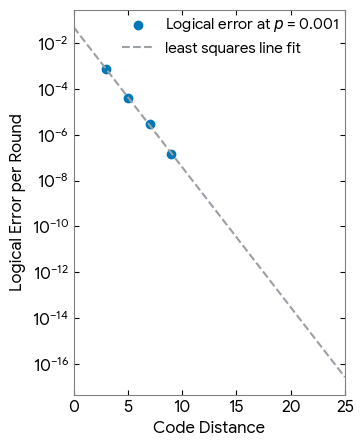

In [11]:
fig, ax = plt.subplots(figsize=(3.5,5))

ax.scatter(xs, ys, label=fr"Logical error at $p$ = {noise}", color = google[0])

ax.plot([0, 25],
        [np.exp(fit.intercept), np.exp(fit.intercept + fit.slope * 25)],
        linestyle='--',
        label='least squares line fit',
        color = google[-1])



ax.set_xlim(0, 25)
plt.tick_params(top=True, left=True, right=True, bottom=True,
               direction="in", axis='both', which='both', 
               labelsize=12, color='k')

ax.semilogy()

font2 = {'family':'Google Sans', 'color':'black', 'size':12}

# ax.set_title("Projecting distance needed to survive a trillion rounds")
plt.xlabel("Code Distance", fontdict = font2)

plt.ylabel("Logical Error per Round", fontdict = font2)

for spine in ax.spines.values():
    spine.set_edgecolor('gray')


plt.legend(
    fontsize=11,  # Slightly smaller font for external legend
    ncol=1,  # Fewer columns for vertical space 
    loc='best', 
    frameon=False,
    borderaxespad=0.  # Removes padding between axes and legend
)
# plt.tight_layout(rect=[0, 0, 1, 1])  # Adjust right margin to make space
plt.savefig('figs/log_err_at_p.jpeg',bbox_inches='tight', dpi = 500)
plt.show()